In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import pandas as pd


In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error



In [13]:
df = pd.read_csv("learn.csv")

X = df[["day", "studied"]]
y = df["knowledge_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Linear Regression RMSE:", rmse_lr)


Linear Regression RMSE: 0.13159735248716678


In [17]:
scaler = MinMaxScaler()
df["knowledge_scaled"] = scaler.fit_transform(
    df[["knowledge_level"]]
)

sequence_length = 10
X_seq, y_seq = [], []

for student in df.student_id.unique():
    student_data = df[df.student_id == student]
    values = student_data["knowledge_scaled"].values

    for i in range(len(values) - sequence_length):
        X_seq.append(values[i:i+sequence_length])
        y_seq.append(values[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)


In [19]:
model = Sequential([
    LSTM(64, input_shape=(sequence_length, 1)),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.fit(
    X_seq, y_seq,
    epochs=20,
    batch_size=32,
    verbose=1
)


C:\Users\Supriya Balakrishna\anaconda3\envs\tfclean\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0256
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0105
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0086
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0077
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0070
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0065
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0061
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0057
Epoch 9/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0056
Epoch 10/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0054
Epoch 11/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0053
Epoch 12/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0052
Epoch 13/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0051
Epoch 14/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0050
Epoch 15/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - l

In [21]:
y_pred_lstm = model.predict(X_seq)

rmse_lstm = np.sqrt(mean_squared_error(y_seq, y_pred_lstm))
print("LSTM RMSE:", rmse_lstm)


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
LSTM RMSE: 0.06974460248977092


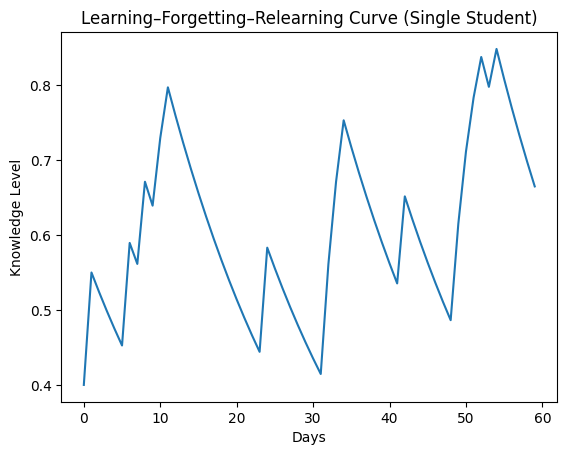

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("learn.csv")

student_id = 0
student_data = df[df.student_id == student_id]

plt.figure()
plt.plot(student_data.day, student_data.knowledge_level)
plt.xlabel("Days")
plt.ylabel("Knowledge Level")
plt.title("Learning–Forgetting–Relearning Curve (Single Student)")
plt.show()


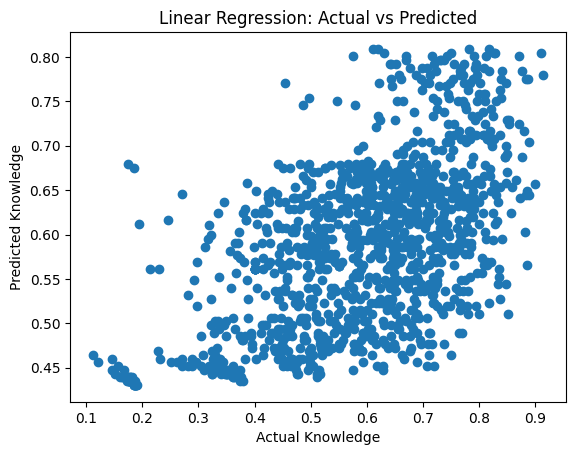

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[["day", "studied"]]
y = df["knowledge_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Knowledge")
plt.ylabel("Predicted Knowledge")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()


C:\Users\Supriya Balakrishna\anaconda3\envs\tfclean\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


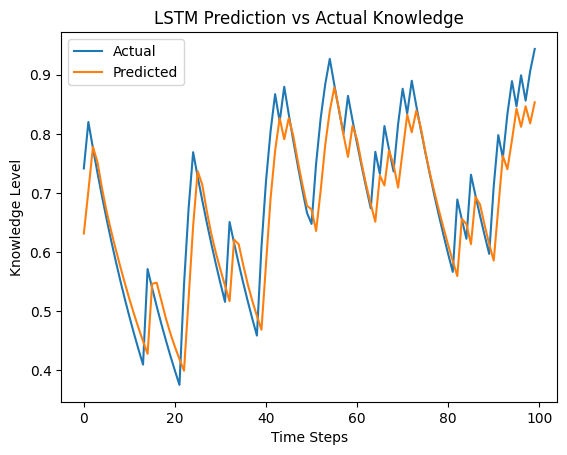

In [27]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

scaler = MinMaxScaler()
df["knowledge_scaled"] = scaler.fit_transform(df[["knowledge_level"]])

sequence_length = 10
X_seq, y_seq = [], []

for student in df.student_id.unique():
    values = df[df.student_id == student]["knowledge_scaled"].values
    for i in range(len(values) - sequence_length):
        X_seq.append(values[i:i+sequence_length])
        y_seq.append(values[i+sequence_length])

X_seq = np.array(X_seq).reshape(-1, sequence_length, 1)
y_seq = np.array(y_seq)

model = Sequential([
    LSTM(64, input_shape=(sequence_length, 1)),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X_seq, y_seq, epochs=10, batch_size=32, verbose=0)

y_pred_lstm = model.predict(X_seq)

plt.figure()
plt.plot(y_seq[:100], label="Actual")
plt.plot(y_pred_lstm[:100], label="Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Knowledge Level")
plt.title("LSTM Prediction vs Actual Knowledge")
plt.legend()
plt.show()


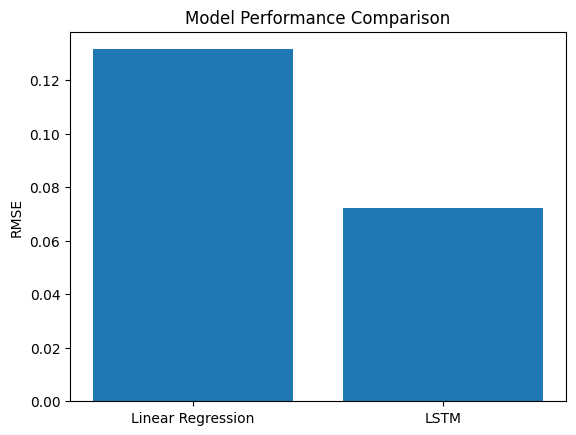

In [29]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
rmse_lstm = np.sqrt(mean_squared_error(y_seq, y_pred_lstm))

models = ["Linear Regression", "LSTM"]
rmse_values = [rmse_lr, rmse_lstm]

plt.figure()
plt.bar(models, rmse_values)
plt.ylabel("RMSE")
plt.title("Model Performance Comparison")
plt.show()
